In [1]:
import pandas as pd
import numpy as np
import sns
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv('./data/sign_mnist_train.csv')
test = pd.read_csv('./data/sign_mnist_test.csv')

In [66]:
test

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,6,149,149,150,150,150,151,151,150,151,...,138,148,127,89,82,96,106,112,120,107
1,5,126,128,131,132,133,134,135,135,136,...,47,104,194,183,186,184,184,184,182,180
2,10,85,88,92,96,105,123,135,143,147,...,68,166,242,227,230,227,226,225,224,222
3,0,203,205,207,206,207,209,210,209,210,...,154,248,247,248,253,236,230,240,253,255
4,3,188,191,193,195,199,201,202,203,203,...,26,40,64,48,29,46,49,46,46,53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7167,1,135,119,108,102,105,99,61,103,121,...,108,112,116,114,118,180,184,176,167,163
7168,12,157,159,161,164,166,166,171,174,175,...,213,213,213,214,213,211,210,210,209,208
7169,2,190,191,190,191,190,190,192,192,191,...,216,215,213,214,214,213,210,211,209,208
7170,4,201,205,208,209,214,216,218,223,226,...,112,169,255,255,237,113,91,67,70,63


In [4]:
train_label = train.iloc[:,:1]
test_label = test.iloc[:,:1]
train_set = train.iloc[:,1:]
test_set = test.iloc[:,1:]

In [5]:
train_set = tf.convert_to_tensor(train_set / 255.0)
test_set = tf.convert_to_tensor(test_set / 255.0)
train_label = tf.keras.utils.to_categorical(train_label)

In [6]:
train_set = tf.reshape(train_set, [-1, 28, 28,1])
test_set = tf.reshape(test_set, [-1, 28, 28,1])

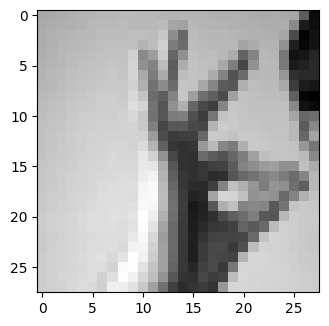

In [7]:
import random

def show_images(image):
    image = image.numpy().reshape(28,28)
    plt.figure(figsize=(8, 8))
    plt.subplot(1,2,2)
    plt.imshow(image, cmap='gray')

# for number_image in range(10):
#     show_images(train[number_image])

show_images(train_set[random.randrange(0,len(train_set)-1)])

In [8]:
train_label = tf.convert_to_tensor(train_label)
test_label = tf.convert_to_tensor(test_label)

In [9]:
train_ds = tf.data.Dataset.from_tensor_slices((train_set, train_label))
test_ds = tf.data.Dataset.from_tensor_slices((test_set, test_label))

In [10]:
# image_gen = tf.keras.preprocessing.image.ImageDataGenerator(
#     rescale=1./255.0,
#     rotation_range=40,
#     width_shift_range=0.2,
#     height_shift_range=0.2,
#     zoom_range=0.2,
#     shear_range=0.2,
#     fill_mode='nearest'
# )

In [11]:
# train_ds = image_gen.flow(
#     x=train,
#     y=train_label,
#     batch_size=32
# )
# test_ds = image_gen.flow(
#     x=test,
#     y=test_label,
#     batch_size=32
# )

In [12]:
final_train_ds, final_val_ds = tf.keras.utils.split_dataset(train_ds, left_size=0.8)

In [13]:
final_train_ds = final_train_ds.shuffle(1000).batch(32)
final_val_ds = final_val_ds.batch(32)

In [14]:
aug = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2)
])

In [15]:
model = tf.keras.Sequential([])
model.add(tf.keras.Input(shape=(28,28,1)))
model.add(aug)
model.add(tf.keras.layers.Conv2D(32, (5,5), activation='relu',padding='same'))
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Conv2D(64, (5,5), activation='relu',padding='same'))
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128, activation='relu'))
# model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(25, activation='softmax'))

In [16]:
adam_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

In [17]:
model.compile(loss='categorical_crossentropy', optimizer=adam_optimizer, metrics=['accuracy'])

In [18]:
history = model.fit(final_train_ds, epochs=10, validation_data=final_val_ds)

Epoch 1/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.2657 - loss: 2.3328 - val_accuracy: 0.5320 - val_loss: 1.3461
Epoch 2/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6203 - loss: 1.1200 - val_accuracy: 0.8026 - val_loss: 0.5926
Epoch 3/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.7775 - loss: 0.6473 - val_accuracy: 0.8816 - val_loss: 0.3610
Epoch 4/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8506 - loss: 0.4320 - val_accuracy: 0.9304 - val_loss: 0.2206
Epoch 5/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8872 - loss: 0.3290 - val_accuracy: 0.9574 - val_loss: 0.1395
Epoch 6/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9179 - loss: 0.2443 - val_accuracy: 0.9443 - val_loss: 0.1550
Epoch 7/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9341 - loss: 0.1953 - val_accuracy: 0.9479 - val_loss: 0.1421
Epoch 8/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9449 - loss: 0.1631 - val_ac

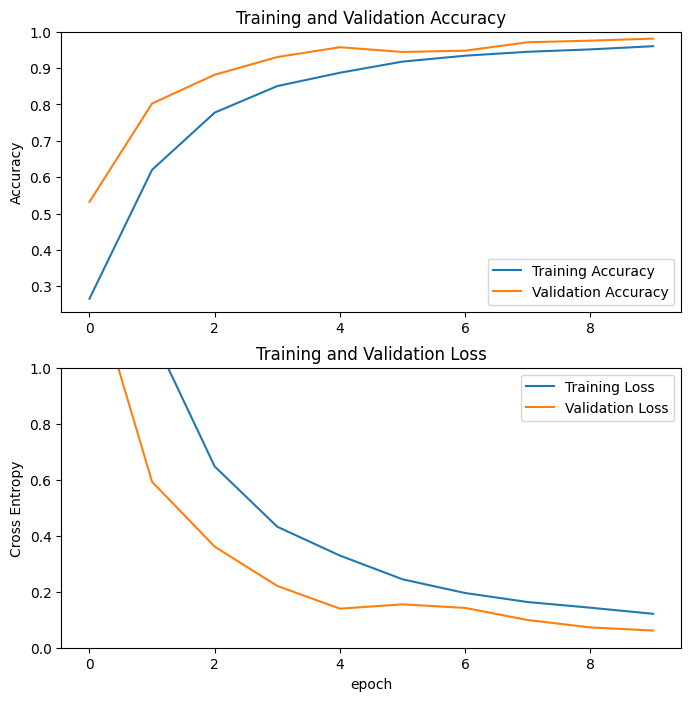

In [19]:

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [20]:
prediction = model.predict(test_set)

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [21]:
predicted_labels = []
for i in range(0,len(test)):
    predicted_labels.append(np.argmax(prediction[i]))

In [67]:
predicted_labels = np.array(predicted_labels)
print(predicted_labels[31])

8


In [23]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_label,predicted_labels)

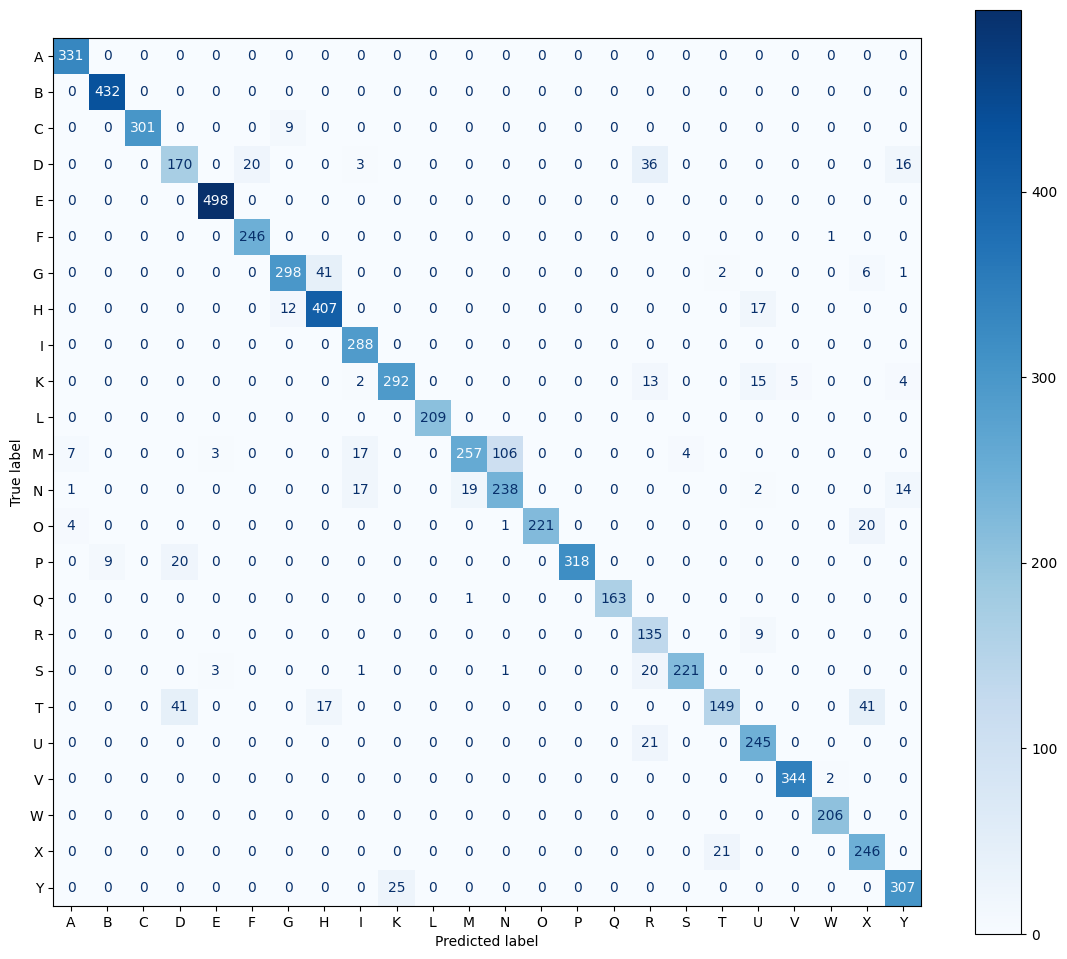

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay
alphabet = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=alphabet)
#make the Confusion Matrix bigger: https://stackoverflow.com/questions/66483409/adjust-size-of-confusionmatrixdisplay-scikitlearn
fig, ax = plt.subplots(figsize=(14,12)) 
display_cm.plot(ax=ax,cmap="Blues")

In [25]:
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score, classification_report

f1_score = f1_score(test_label,predicted_labels,average='weighted')
accuracy_score = accuracy_score(test_label,predicted_labels)
recall_score = recall_score(test_label,predicted_labels,average='weighted')
precision_score = precision_score(test_label,predicted_labels,average='weighted')

classification_report = classification_report(test_label,predicted_labels)

In [26]:
print(classification_report)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       331
           1       0.98      1.00      0.99       432
           2       1.00      0.97      0.99       310
           3       0.74      0.69      0.71       245
           4       0.99      1.00      0.99       498
           5       0.92      1.00      0.96       247
           6       0.93      0.86      0.89       348
           7       0.88      0.93      0.90       436
           8       0.88      1.00      0.94       288
          10       0.92      0.88      0.90       331
          11       1.00      1.00      1.00       209
          12       0.93      0.65      0.77       394
          13       0.69      0.82      0.75       291
          14       1.00      0.90      0.95       246
          15       1.00      0.92      0.96       347
          16       1.00      0.99      1.00       164
          17       0.60      0.94      0.73       144
          18       0.98    

In [27]:
print(f1_score)
print(accuracy_score)
print(recall_score)
print(precision_score)

0.9087186609260525
0.9093697713329615
0.9093697713329615
0.9161619135826473


In [41]:
def return_alphabet(num):
    alphabet = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']
    if num > 8:
        return alphabet[num-1]
    else:
        return alphabet[num]

8
Test Label: I
Predicted Label: I


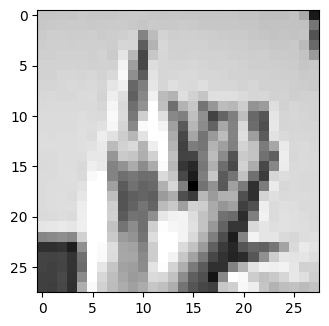

In [54]:
random_number = 10
print(int(test_label[random_number][0]))
print("Test Label:", return_alphabet(int(test_label[random_number][0])))
print("Predicted Label:", return_alphabet(predicted_labels[random_number]))
show_images(test_set[random_number])

In [30]:
train['label'].unique()

array([ 3,  6,  2, 13, 16,  8, 22, 18, 10, 20, 17, 19, 21, 23, 24,  1, 12,
       11, 15,  4,  0,  5,  7, 14])

In [31]:
np.unique(predicted_labels)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])

In [32]:
np.argmax(predicted_labels)

np.int64(4)